<a href="https://colab.research.google.com/github/Hadia-git-sketch/ArchTechnologies_2nd_MonthTasks/blob/main/house_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

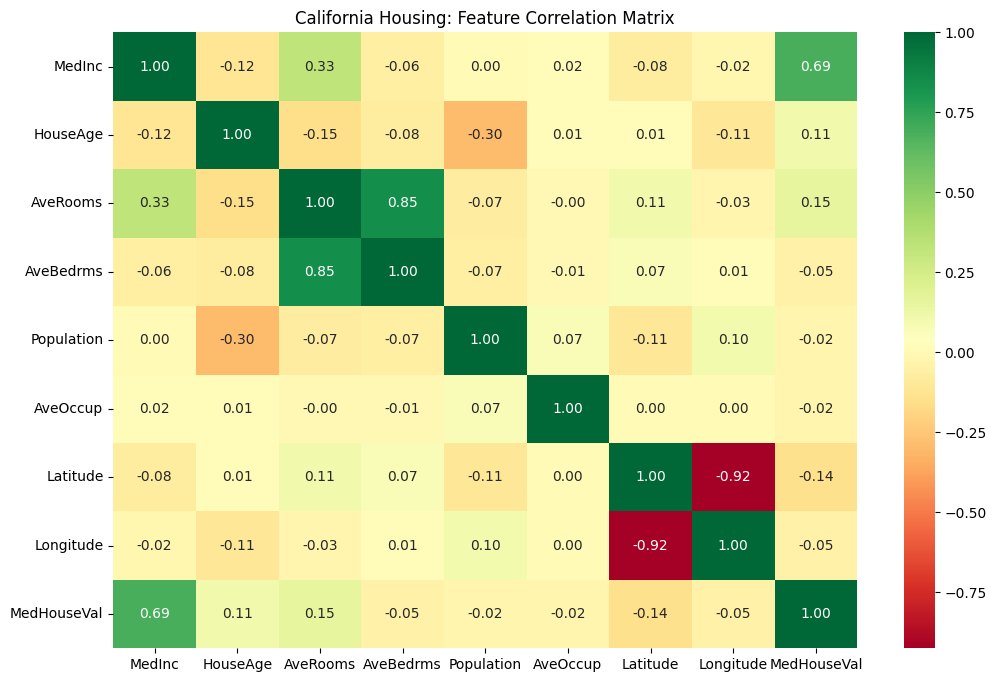

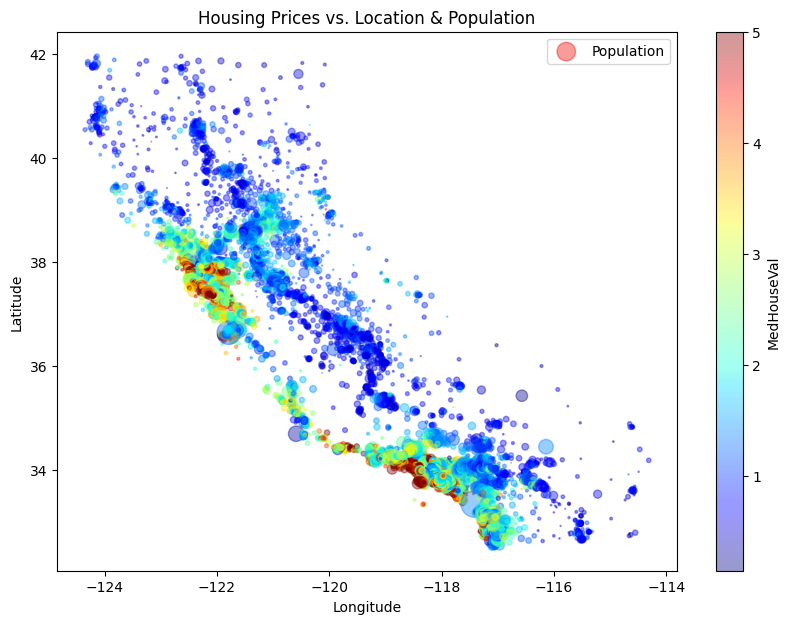


--- Model Performance ---
RMSE: 0.7456
R2 Score: 0.5758
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://716fa557cda75c8862.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import pandas as pd
import numpy as np
import joblib
import gradio as gr
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# 1. DATA LOADING
# The fetch_california_housing dataset returns specific capitalized column names
data = fetch_california_housing(as_frame=True)
df = data.frame

# 2. EXPLORATORY DATA ANALYSIS (Graphs)
# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title("California Housing: Feature Correlation Matrix")
plt.show()

# Geographical Scatter Plot (Fixed the KeyError by using correct column cases)
df.plot(kind="scatter", x="Longitude", y="Latitude", alpha=0.4,
        s=df["Population"]/100, label="Population", figsize=(10,7),
        c="MedHouseVal", cmap=plt.get_cmap("jet"), colorbar=True)
plt.title("Housing Prices vs. Location & Population")
plt.legend()
plt.show()

# 3. DATA PREPROCESSING
# Target is MedHouseVal (Median House Value)
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

# Split: 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling is essential for Linear Regression with this dataset
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. MODEL TRAINING
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Save the model and the scaler (needed for Gradio later)
joblib.dump(model, 'cali_model.pkl')
joblib.dump(scaler, 'cali_scaler.pkl')

# 5. EVALUATION
y_pred = model.predict(X_test_scaled)
print("\n--- Model Performance ---")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")

# 6. GRADIO INTERFACE
def predict_house_value(income, age, rooms, bedrooms, pop, occup, lat, lon):
    # Load the saved model and scaler
    trained_model = joblib.load('cali_model.pkl')
    trained_scaler = joblib.load('cali_scaler.pkl')

    # Create input array with exact feature order
    input_data = np.array([[income, age, rooms, bedrooms, pop, occup, lat, lon]])

    # Scale the user input using the training scaler
    input_scaled = trained_scaler.transform(input_data)

    # Predict (Result is in units of $100,000)
    prediction = trained_model.predict(input_scaled)[0]

    # Return formatted string (ensuring no negative values)
    final_price = max(0, prediction * 100000)
    return f"${final_price:,.0f}"

# Define the UI
app = gr.Interface(
    fn=predict_house_value,
    inputs=[
        gr.Slider(0, 15, label="Median Income (Units of $10k)", value=3.5),
        gr.Slider(1, 52, label="House Age", value=28),
        gr.Number(label="Average Rooms", value=5),
        gr.Number(label="Average Bedrooms", value=1),
        gr.Number(label="Population", value=1400),
        gr.Number(label="Average Occupancy", value=3),
        gr.Number(label="Latitude (e.g., 34.05)", value=34.05),
        gr.Number(label="Longitude (e.g., -118.24)", value=-118.24)
    ],
    outputs=gr.Textbox(label="Predicted Median House Value"),
    title="California Housing Price Prediction System",
    description="Enter neighborhood details to estimate house prices based on the California Census dataset."
)

if __name__ == "__main__":
    app.launch(share=True) # share=True creates a public link in Colab